In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve, f1_score
import xgboost as xgb

In [3]:
credit_card_df = pd.read_csv('creditcard.csv')
credit_card_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Dataset shape:", credit_card_df.shape)
print("\nFirst few rows:")
print(credit_card_df.head())
print("\nColumn names and types:")
print(credit_card_df.dtypes)
print("\nMissing values:")
print(credit_card_df.isnull().sum())
print("\nBasic statistics:")
print(credit_card_df.describe())

Dataset shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -

In [5]:
# Check fraud distribution
fraud_counts = credit_card_df['Class'].value_counts()
fraud_pct = credit_card_df['Class'].value_counts(normalize=True) * 100

print("Fraud distribution:")
print(fraud_counts)
print("Fraut percentage:")
print(fraud_pct)

Fraud distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraut percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Feature statistics:
                 V1            V2            V3         Amount           Time
count  2.848070e+05  2.848070e+05  2.848070e+05  284807.000000  284807.000000
mean   1.168375e-15  3.416908e-16 -1.379537e-15      88.349619   94813.859575
std    1.958696e+00  1.651309e+00  1.516255e+00     250.120109   47488.145955
min   -5.640751e+01 -7.271573e+01 -4.832559e+01       0.000000       0.000000
25%   -9.203734e-01 -5.985499e-01 -8.903648e-01       5.600000   54201.500000
50%    1.810880e-02  6.548556e-02  1.798463e-01      22.000000   84692.000000
75%    1.315642e+00  8.037239e-01  1.027196e+00      77.165000  139320.500000
max    2.454930e+00  2.205773e+01  9.382558e+00   25691.160000  172792.000000

Correlation with fraud:
Amount correlation: 0.0056
Time correlation: -0.0123


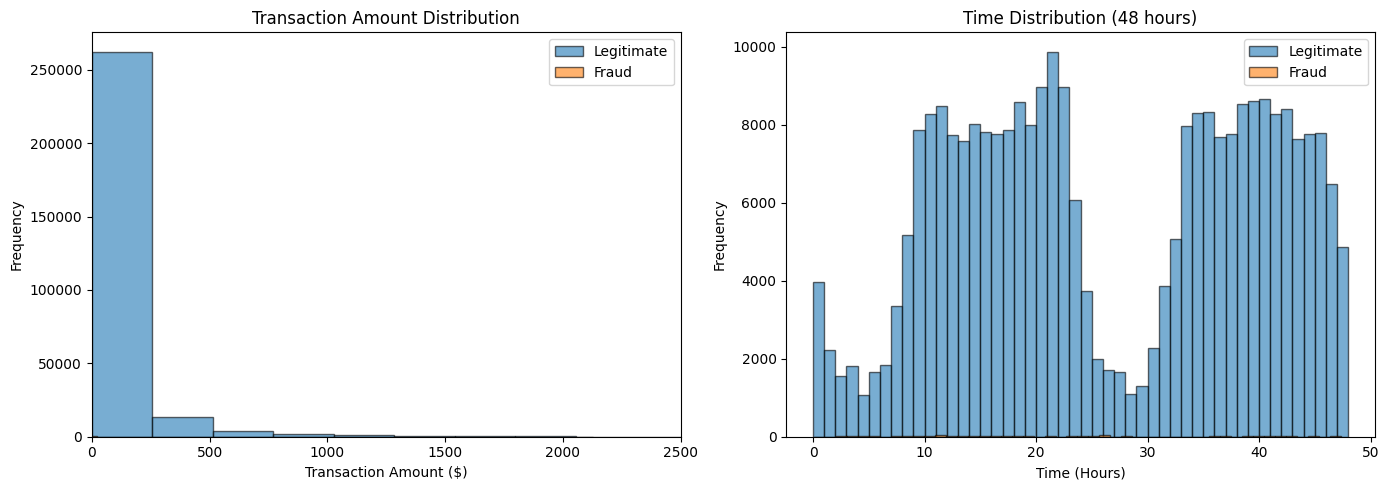


Legitimate transactions:
  Average amount: $88.29
  Median amount: $22.00
  Std dev: $250.11

Fraud transactions:
  Average amount: $122.21
  Median amount: $9.25
  Std dev: $256.68

Correlation with fraud (top 10 features):
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64


In [6]:
# The V1-V28 features are PCA-transformed (already scaled by Kaggle)
# We can still understand their distribution

print("Feature statistics:")
print(credit_card_df[['V1', 'V2', 'V3', 'Amount', 'Time']].describe())

# Correlation of Amount and Time with fraud
print("\nCorrelation with fraud:")
print(f"Amount correlation: {credit_card_df['Amount'].corr(credit_card_df['Class']):.4f}")
print(f"Time correlation: {credit_card_df['Time'].corr(credit_card_df['Class']):.4f}")

# Visualize Amount and Time by fraud status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution
axes[0].hist(credit_card_df[credit_card_df['Class'] == 0]['Amount'], bins=100, alpha=0.6, label='Legitimate', edgecolor='black')
axes[0].hist(credit_card_df[credit_card_df['Class'] == 1]['Amount'], bins=100, alpha=0.6, label='Fraud', edgecolor='black')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()
axes[0].set_xlim([0, 2500])  # Focus on main distribution

# Time distribution (in hours for readability)
axes[1].hist(credit_card_df[credit_card_df['Class'] == 0]['Time'] / 3600, bins=48, alpha=0.6, label='Legitimate', edgecolor='black')
axes[1].hist(credit_card_df[credit_card_df['Class'] == 1]['Time'] / 3600, bins=48, alpha=0.6, label='Fraud', edgecolor='black')
axes[1].set_xlabel('Time (Hours)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Time Distribution (48 hours)')
axes[1].legend()

plt.tight_layout()
plt.savefig('feature_exploration.png', dpi=300)
plt.show()

# Summary statistics by class
print("\nLegitimate transactions:")
print(f"  Average amount: ${credit_card_df[credit_card_df['Class'] == 0]['Amount'].mean():.2f}")
print(f"  Median amount: ${credit_card_df[credit_card_df['Class'] == 0]['Amount'].median():.2f}")
print(f"  Std dev: ${credit_card_df[credit_card_df['Class'] == 0]['Amount'].std():.2f}")

print("\nFraud transactions:")
print(f"  Average amount: ${credit_card_df[credit_card_df['Class'] == 1]['Amount'].mean():.2f}")
print(f"  Median amount: ${credit_card_df[credit_card_df['Class'] == 1]['Amount'].median():.2f}")
print(f"  Std dev: ${credit_card_df[credit_card_df['Class'] == 1]['Amount'].std():.2f}")

# Correlation matrix (sample for readability)
print("\nCorrelation with fraud (top 10 features):")
correlations = credit_card_df.corr()['Class'].drop('Class').sort_values(ascending=False)
print(correlations.head(10))

In [26]:
# Creat a copy for cleaning
df_clean = credit_card_df.copy()

# Chevk for missing values
print('Missing values:')
print(df_clean.isnull().sum())

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [27]:
def engineer_features(df):
    """
    Create new features from Time and Amount
    """
    df = df.copy()
    
    df['time_hours'] = df['Time'] / 3600
    df['time_days'] = df['Time'] / (3600 * 24)
    
    # Hour of day (assuming data spans ~2 days, 48 hours)
    df['hour_of_day'] = (df['Time'] / 3600) % 24
    
    # Time-of-day category
    def categorize_time(hour):
        if 0 <= hour < 6:
            return 'night'  # 12am-6am (risky)
        elif 6 <= hour < 12:
            return 'morning'
        elif 12 <= hour < 18:
            return 'afternoon'
        else:
            return 'evening'
    
    df['time_category'] = df['hour_of_day'].apply(categorize_time)
    
    # ===== AMOUNT-BASED FEATURES =====
    # Amount statistics (rolling window style)
    # These simulate user behavior patterns
    
    # Flag for zero amount
    df['is_zero_amount'] = (df['Amount'] == 0).astype(int)
    
    # Log amount (safer for skewed distributions)
    df['log_amount'] = np.log1p(df['Amount'])  # log1p handles zeros
    
    # Amount buckets
    df['amount_bucket'] = pd.qcut(df['Amount'], q=5, labels=False, duplicates='drop')
    
    # ===== INTERACTION FEATURES =====
    # Interaction: Small amount + night time (common fraud pattern)
    df['small_amount_night'] = ((df['Amount'] < df['Amount'].median()) & 
                                (df['hour_of_day'] >= 22) | 
                                (df['hour_of_day'] < 6)).astype(int)
    
    # Interaction: Large amount (high fraud risk)
    df['large_amount'] = (df['Amount'] > df['Amount'].quantile(0.95)).astype(int)
    
    # ===== STATISTICAL FEATURES (Sliding window aggregation) =====
    # These are computed per time window to capture patterns
    
    # Amount statistics in 1-hour windows
    window_size = 3600  # 1 hour in seconds
    df['amount_mean_1h'] = df.set_index('Time')['Amount'].rolling(window=window_size, min_periods=1).mean().reset_index(drop=True)
    df['amount_std_1h'] = df.set_index('Time')['Amount'].rolling(window=window_size, min_periods=1).std().reset_index(drop=True)
    
    # Transaction count in 1-hour window (velocity)
    df['txn_count_1h'] = df.set_index('Time').index.to_series().rolling(window=window_size, min_periods=1).count().reset_index(drop=True)
    
    # Normalize for use
    df['amount_std_1h'].fillna(0, inplace=True)
    
    return df

print("Creating features...")
df_clean = engineer_features(df_clean)

print("\nNew features created:")
print(df_clean[['Amount', 'log_amount', 'amount_bucket', 'hour_of_day', 
                 'time_category', 'large_amount', 'amount_mean_1h']].head(20))

Creating features...

New features created:
    Amount  log_amount  amount_bucket  hour_of_day time_category  \
0   149.62    5.014760              4     0.000000         night   
1     2.69    1.305626              0     0.000000         night   
2   378.66    5.939276              4     0.000278         night   
3   123.50    4.824306              4     0.000278         night   
4    69.99    4.262539              3     0.000556         night   
5     3.67    1.541159              1     0.000556         night   
6     4.99    1.790091              1     0.001111         night   
7    40.80    3.732896              3     0.001944         night   
8    93.20    4.545420              3     0.001944         night   
9     3.68    1.543298              1     0.002500         night   
10    7.80    2.174752              1     0.002778         night   
11    9.99    2.396986              1     0.002778         night   
12  121.50    4.808111              4     0.002778         night   
13  

/var/folders/wn/7lns8n057cz4jzhzfv16rs_c0000gn/T/ipykernel_77201/3772557870.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['amount_std_1h'].fillna(0, inplace=True)


In [28]:
# One-hot encode time_category
df_clean = pd.get_dummies(df_clean, columns=['time_category'], prefix='time', drop_first=True)

print("Categorical encoding complete!")
print(f"New columns after encoding: {df_clean.columns.tolist()}")

Categorical encoding complete!
New columns after encoding: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'time_hours', 'time_days', 'hour_of_day', 'is_zero_amount', 'log_amount', 'amount_bucket', 'small_amount_night', 'large_amount', 'amount_mean_1h', 'amount_std_1h', 'txn_count_1h', 'time_evening', 'time_morning', 'time_night']


In [29]:
# Identify all features to use
# Include: V1-V28 (PCA features) + engineered features + Amount
# Exclude: Time (we've extracted features from it), Class (target)

base_features = [col for col in df_clean.columns if col.startswith('V')]  # V1-V28
engineered_features = ['Amount', 'log_amount', 'hour_of_day', 'is_zero_amount',
                       'large_amount', 'small_amount_night', 'amount_mean_1h', 
                       'amount_std_1h', 'txn_count_1h']
categorical_features = [col for col in df_clean.columns if col.startswith('time_')]

all_features = base_features + engineered_features + categorical_features

print(f"Total features: {len(all_features)}")
print("\nFeature breakdown:")
print(f"  PCA features (V1-V28): {len(base_features)}")
print(f"  Engineered features: {len(engineered_features)}")
print(f"  Categorical features: {len(categorical_features)}")

print("\nFull feature list:")
for i, feat in enumerate(all_features, 1):
    print(f"{i}. {feat}")

# Handle any NaN values created during feature engineering
print("\nChecking for NaN values in features:")
print(df_clean[all_features].isnull().sum())

# Fill remaining NaNs with 0
# df_clean[all_features] = df_clean[all_features].fillna(0)

Total features: 42

Feature breakdown:
  PCA features (V1-V28): 28
  Engineered features: 9
  Categorical features: 5

Full feature list:
1. V1
2. V2
3. V3
4. V4
5. V5
6. V6
7. V7
8. V8
9. V9
10. V10
11. V11
12. V12
13. V13
14. V14
15. V15
16. V16
17. V17
18. V18
19. V19
20. V20
21. V21
22. V22
23. V23
24. V24
25. V25
26. V26
27. V27
28. V28
29. Amount
30. log_amount
31. hour_of_day
32. is_zero_amount
33. large_amount
34. small_amount_night
35. amount_mean_1h
36. amount_std_1h
37. txn_count_1h
38. time_hours
39. time_days
40. time_evening
41. time_morning
42. time_night

Checking for NaN values in features:
V1                    0
V2                    0
V3                    0
V4                    0
V5                    0
V6                    0
V7                    0
V8                    0
V9                    0
V10                   0
V11                   0
V12                   0
V13                   0
V14                   0
V15                   0
V16                   0
V

In [30]:
# Separate features and target variable
X = df_clean[all_features].copy()
y = df_clean['Class'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print(f"\nTraining set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")
print(f"Train fraud rate: {y_train.mean():.4%}")
print(f"Test fraud rate: {y_test.mean():.4%}")


Training set size: 227,845
Test set size: 56,962
Train fraud rate: 0.1729%
Test fraud rate: 0.1720%


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=all_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=all_features, index=X_test.index)

print("Features scaled!")
print(f"Training set mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"Training set std (should be ~1): {X_train_scaled.std().mean():.6f}")

Features scaled!
Training set mean (should be ~0): -0.000000
Training set std (should be ~1): 1.000002


In [32]:
from imblearn.over_sampling import SMOTE

print(f"Original training set fraud distribution:")
print(y_train.value_counts())
print(f"Fraud ratio: {y_train.mean():.4f}")

# SMOTE: Synthetic Minority Oversampling Technique
# This creates synthetic fraud examples to balance the data
smote = SMOTE(random_state=42, sampling_strategy=0.3)  # Balance to 30% minority
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
print(f"New training set size: {len(X_train_balanced):,}")
print(f"New fraud ratio: {pd.Series(y_train_balanced).mean():.4%}")

# For tree-based models, we'll use scale_pos_weight instead
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"\nClass weight ratio for tree models: {scale_pos_weight:.2f}")
print(f"(means: penalize fraud misclassification {scale_pos_weight:.0f}x more)")

Original training set fraud distribution:
Class
0    227451
1       394
Name: count, dtype: int64
Fraud ratio: 0.0017

After SMOTE:
Class
0    227451
1     68235
Name: count, dtype: int64
New training set size: 295,686
New fraud ratio: 23.0768%

Class weight ratio for tree models: 577.29
(means: penalize fraud misclassification 577x more)


/opt/anaconda3/envs/fraud_detection/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [33]:
print("=" * 70)
print("MODEL 1: LOGISTIC REGRESSION (Interpretable Baseline)")
print("=" * 70)

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs")

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:,1]

print("\nLogistic Regression Performance:")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate','Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

# Feature importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'feature': all_features,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 15 important features (by coefficient magnitude):")
print(feature_importance_lr.head(15))

MODEL 1: LOGISTIC REGRESSION (Interpretable Baseline)

Logistic Regression Performance:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.90      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9553

Top 15 important features (by coefficient magnitude):
         feature  coefficient
36  txn_count_1h     2.502921
28        Amount     2.450374
0             V1     2.053935
13           V14    -1.552932
9            V10    -1.514288
4             V5     1.479843
3             V4     1.466309
11           V12    -1.266845
16           V17    -1.099527
19           V20    -1.052409
1             V2     1.036921
15           V16    -1.007617
6             V7    -0.877792
39  time_evening     0.829628
21           V22     0.783068


In [34]:
print("\n" + "=" * 70)
print("MODEL 2: XGBOOST (High Performance)")
print("=" * 70)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0)

xgb_model.fit(X_train_scaled, y_train,
              eval_set=[(X_test_scaled, y_test)],
              verbose=False)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]
# Evaluate
print("\nXGBoost Performance:")
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'feature': all_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 important features:")
print(feature_importance_xgb.head(15))


MODEL 2: XGBOOST (High Performance)

XGBoost Performance:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9807

Top 15 important features:
         feature  importance
13           V14    0.390696
9            V10    0.087786
3             V4    0.063142
39  time_evening    0.042893
29    log_amount    0.032506
11           V12    0.028515
19           V20    0.025485
28        Amount    0.021100
7             V8    0.019430
12           V13    0.017284
18           V19    0.017120
25           V26    0.015645
6             V7    0.015468
0             V1    0.014702
30   hour_of_day    0.013110


In [35]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    Comprehensive evaluation for imbalanced classification
    """
    print(f"\n{'='*70}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*70}")
    
     # Classification metrics
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Fraud']))
    
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)
    print(f"Precision-Recall AUC: {pr_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives (TN):  {tn:7d} | False Positives (FP): {fp:7d}")
    print(f"  False Negatives (FN): {fn:7d} | True Positives (TP):  {tp:7d}")
    
    # Custom metrics for fraud
    fraud_detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    print(f"\nKey Metrics:")
    print(f"  Fraud Detection Rate (Recall): {fraud_detection_rate:.4%}")
    print(f"  False Positive Rate: {false_positive_rate:.4%}")
    
    return {
        'model': model_name,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'fraud_detection_rate': fraud_detection_rate,
        'false_positive_rate': false_positive_rate,
        'f1_score': f1_score(y_true, y_pred)
    }

results_list = []
results_list.append(evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, 'Logistic Regression'))
results_list.append(evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, 'XGBoost'))

# Create comparison table
results_df = pd.DataFrame(results_list)
print("\n" + "="*90)
print("MODEL COMPARISON SUMMARY")
print("="*90)
print(results_df.to_string(index=False))


EVALUATION: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.90      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9553
Precision-Recall AUC: 0.7580

Confusion Matrix:
  True Negatives (TN):    55385 | False Positives (FP):    1479
  False Negatives (FN):      10 | True Positives (TP):       88

Key Metrics:
  Fraud Detection Rate (Recall): 89.7959%
  False Positive Rate: 2.6009%

EVALUATION: XGBoost

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg  

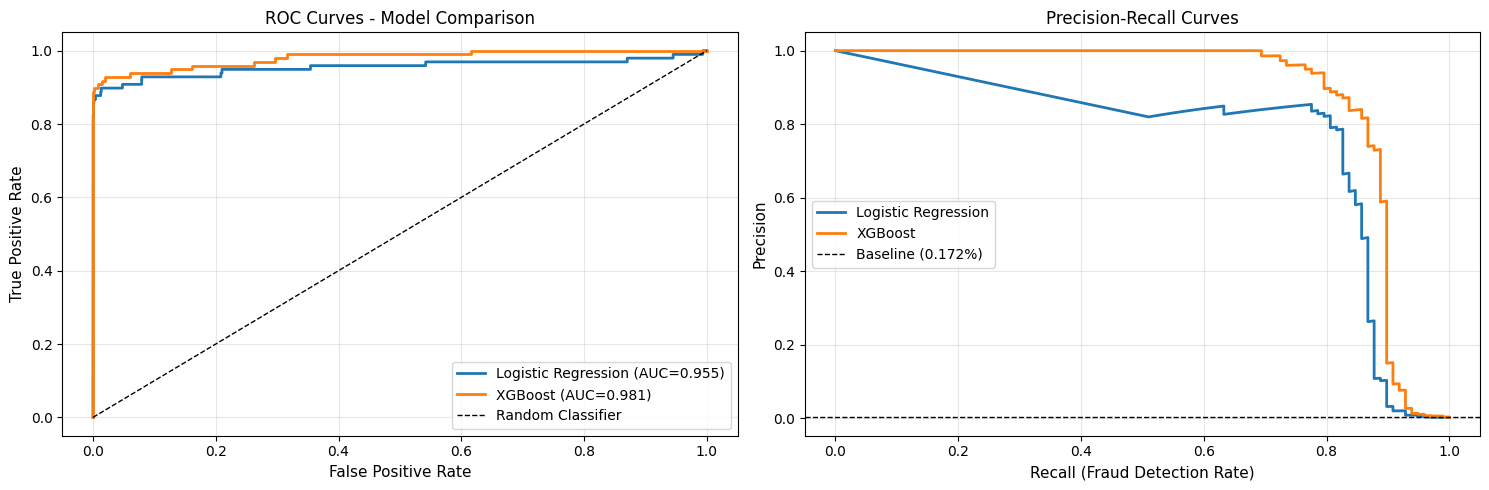

In [36]:
# Plot ROC Curves
plt.figure(figsize=(15, 5))

# ROC Curve
plt.subplot(1, 2, 1)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_pred_proba_lr):.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_pred_proba_xgb):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves - Model Comparison', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Precision-Recall Curve
plt.subplot(1, 2, 2)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)

plt.plot(recall_lr, precision_lr, label='Logistic Regression', linewidth=2)
plt.plot(recall_xgb, precision_xgb, label='XGBoost', linewidth=2)
plt.axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.3%})', linewidth=1)
plt.xlabel('Recall (Fraud Detection Rate)', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curves', fontsize=12)
plt.legend(loc='best')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=300, bbox_inches='tight')
plt.show()

Optimal threshold (F1-score): 0.940
F1-score at optimal threshold: 0.8619


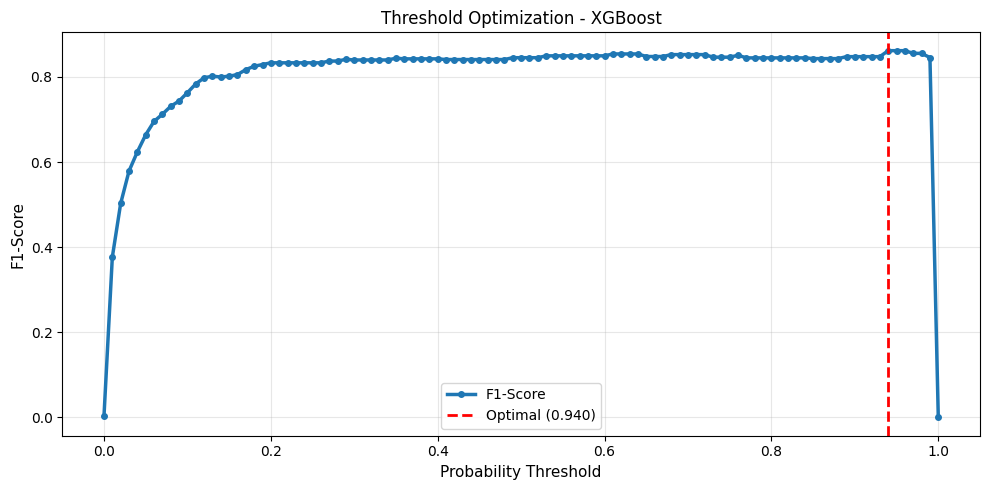

In [37]:
def find_optimal_threshold(y_true, y_pred_proba, metric='f1'):
    """
    Find threshold that optimizes specified metric
    """
    
    thresholds = np.arange(0, 1.01, 0.01)
    scores = []
    
    for threshold in thresholds:
        y_pred_thresh = (y_pred_proba >= threshold).astype(int)
        
        if metric == 'f1':
            score = f1_score(y_true, y_pred_thresh)
        elif metric == 'recall':
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred_thresh).ravel()
            score = tp / (tp + fn) if (tp + fn) > 0 else 0
            
        scores.append(score)
    
    optimal_threshold = thresholds[np.argmax(scores)]
    optimal_score = max(scores)
    
    return optimal_threshold, optimal_score, thresholds, scores
    

# Find optimal threshold for XGBoost (best model)
opt_thresh_f1, opt_score_f1, thresholds, f1_scores = find_optimal_threshold(y_test, y_pred_proba_xgb, metric='f1')

print(f"Optimal threshold (F1-score): {opt_thresh_f1:.3f}")
print(f"F1-score at optimal threshold: {opt_score_f1:.4f}")

# Plot threshold optimization
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, linewidth=2.5, label='F1-Score', marker='o', markersize=4)
plt.axvline(x=opt_thresh_f1, color='r', linestyle='--', linewidth=2, label=f'Optimal ({opt_thresh_f1:.3f})')
plt.xlabel('Probability Threshold', fontsize=11)
plt.ylabel('F1-Score', fontsize=11)
plt.title('Threshold Optimization - XGBoost', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()
    

Computing shap values...


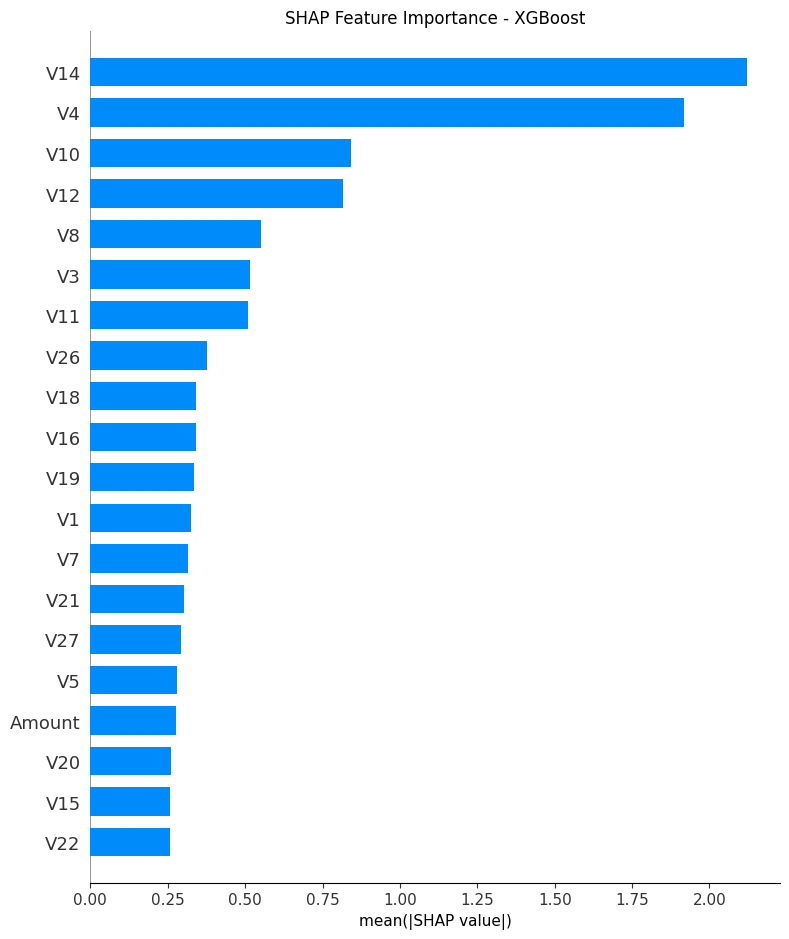

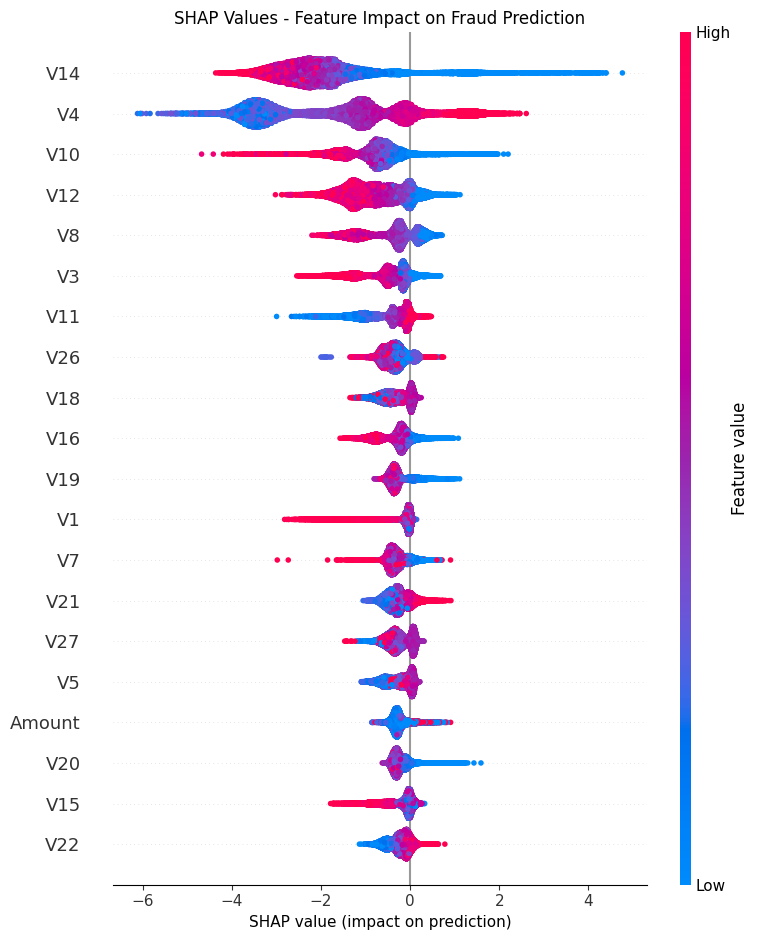

In [40]:
import shap

print("Computing shap values...")

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot (bar chart of feature importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - XGBoost', fontsize=12)
plt.xlabel('mean(|SHAP value|)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed summary plot (shows direction of impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title('SHAP Values - Feature Impact on Fraud Prediction', fontsize=12)
plt.xlabel('SHAP value (impact on prediction)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

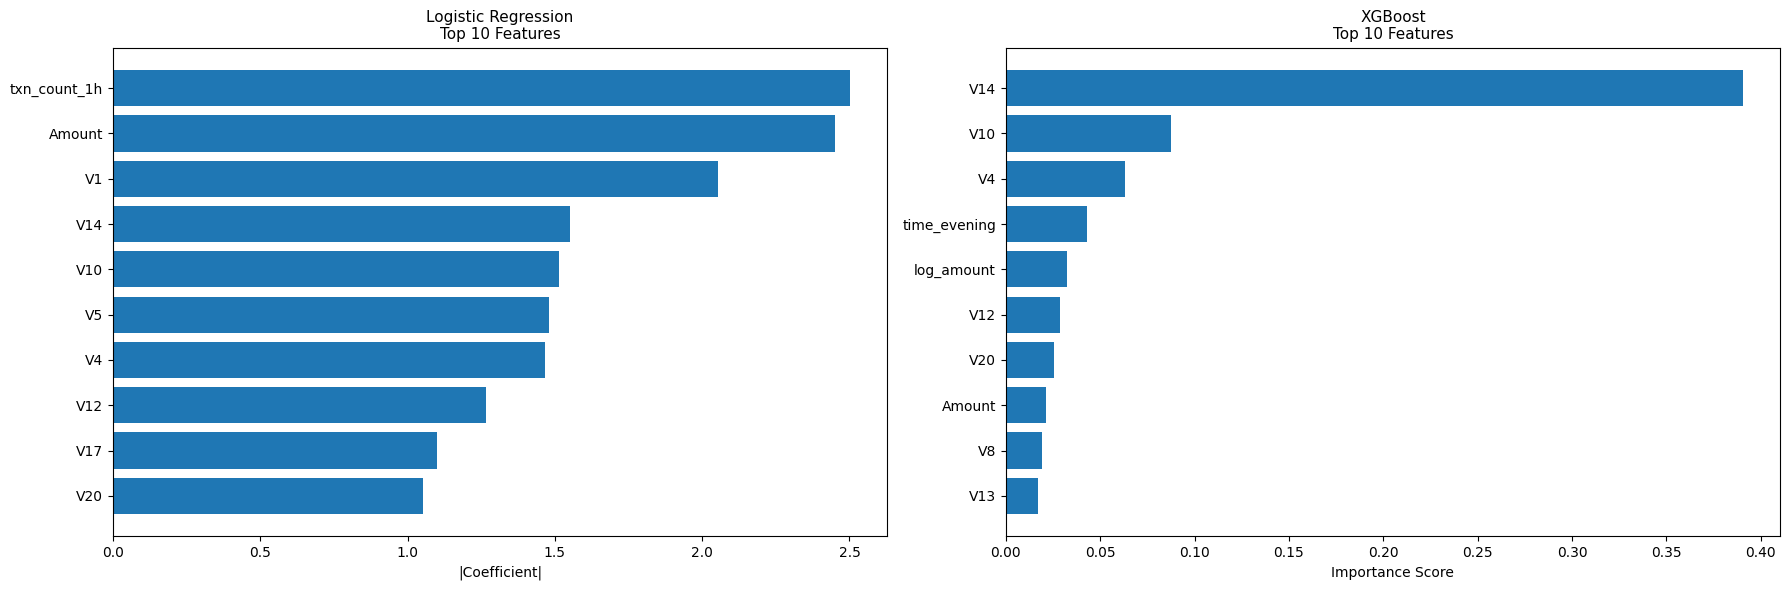

In [42]:
# Compare feature importance across models
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_n = 10

# Logistic Regression
axes[0].barh(range(top_n), feature_importance_lr.head(top_n)['coefficient'].abs())
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(feature_importance_lr.head(top_n)['feature'])
axes[0].set_title('Logistic Regression\nTop 10 Features', fontsize=11)
axes[0].set_xlabel('|Coefficient|', fontsize=10)
axes[0].invert_yaxis()

# XGBoost
axes[1].barh(range(top_n), feature_importance_xgb.head(top_n)['importance'])
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(feature_importance_xgb.head(top_n)['feature'])
axes[1].set_title('XGBoost\nTop 10 Features', fontsize=11)
axes[1].set_xlabel('Importance Score', fontsize=10)
axes[1].invert_yaxis()


plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Sample Risk Scores:
    actual_fraud  fraud_probability  risk_score  predicted_fraud
0              0           0.000024           0                0
1              0           0.000013           0                0
2              0           0.000075           0                0
3              0           0.000003           0                0
4              0           0.000448           0                0
5              0           0.000016           0                0
6              0           0.000005           0                0
7              0           0.000013           0                0
8              0           0.000013           0                0
9              0           0.000015           0                0
10             0           0.000094           0                0
11             0           0.000141           0                0
12             0           0.000023           0                0
13             0           0.000009           0                0
14   

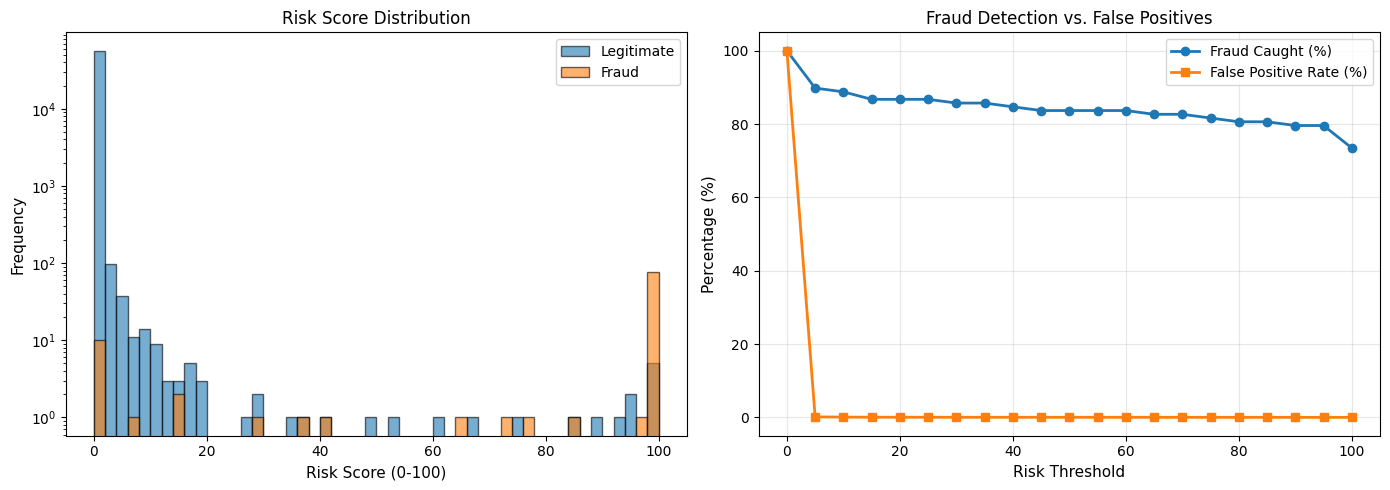


Threshold Impact Analysis:
Risk Threshold  Fraud Caught (%)     False Positive Rate (%)   Total Alerts   
---------------------------------------------------------------------------
0               100.0                100.00                    56,962         
10              88.8                 0.08                      131            
20              86.7                 0.04                      106            
30              85.7                 0.03                      102            
40              84.7                 0.03                      99             
50              83.7                 0.02                      96             
60              83.7                 0.02                      95             
70              82.7                 0.02                      92             
80              80.6                 0.02                      89             
90              79.6                 0.01                      86             
100             73.5       

In [43]:
# Create actionable risk scores (0-100) from probabilities
def create_risk_score(probability):
    """Convert fraud probability to risk score"""
    return (probability * 100).round(0).astype(int)

# Add risk scores to test set
test_results = pd.DataFrame({
    'actual_fraud': y_test.values,
    'fraud_probability': y_pred_proba_xgb,
    'risk_score': create_risk_score(y_pred_proba_xgb),
    'predicted_fraud': (y_pred_proba_xgb >= opt_thresh_f1).astype(int)
})

print("Sample Risk Scores:")
print(test_results.head(20))

# Distribution of risk scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(test_results[test_results['actual_fraud'] == 0]['risk_score'], 
             bins=50, alpha=0.6, label='Legitimate', edgecolor='black')
axes[0].hist(test_results[test_results['actual_fraud'] == 1]['risk_score'], 
             bins=50, alpha=0.6, label='Fraud', edgecolor='black')
axes[0].set_xlabel('Risk Score (0-100)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Risk Score Distribution', fontsize=12)
axes[0].legend()
axes[0].set_yscale('log')  # Log scale to see fraud cases better

# Fraud detection at different thresholds
risk_thresholds = np.arange(0, 101, 5)
fraud_caught = []
false_positives = []
total_alerts = []

for threshold in risk_thresholds:
    flagged = test_results['risk_score'] >= threshold
    fraud_in_flagged = (test_results[flagged]['actual_fraud'] == 1).sum()
    legit_in_flagged = (test_results[flagged]['actual_fraud'] == 0).sum()
    
    fraud_caught.append(fraud_in_flagged / test_results['actual_fraud'].sum() * 100)
    false_positives.append(legit_in_flagged / (test_results['actual_fraud'] == 0).sum() * 100)
    total_alerts.append(flagged.sum())

axes[1].plot(risk_thresholds, fraud_caught, label='Fraud Caught (%)', marker='o', linewidth=2)
axes[1].plot(risk_thresholds, false_positives, label='False Positive Rate (%)', marker='s', linewidth=2)
axes[1].set_xlabel('Risk Threshold', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_title('Fraud Detection vs. False Positives', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('risk_score_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print threshold impact
print("\nThreshold Impact Analysis:")
print(f"{'Risk Threshold':<15} {'Fraud Caught (%)':<20} {'False Positive Rate (%)':<25} {'Total Alerts':<15}")
print("-" * 75)
for i, threshold in enumerate(risk_thresholds[::2]):  # Every other threshold for clarity
    print(f"{threshold:<15.0f} {fraud_caught[i*2]:<20.1f} {false_positives[i*2]:<25.2f} {total_alerts[i*2]:<15,}")

In [46]:
print("\n" + "="*80)
print("BUSINESS IMPACT SUMMARY")
print("="*80)

# Dataset statistics
total_transactions = len(credit_card_df)
total_fraud_count = credit_card_df['Class'].sum()
total_fraud_amount = credit_card_df[credit_card_df['Class'] == 1]['Amount'].sum()
avg_fraud_amount = credit_card_df[credit_card_df['Class'] == 1]['Amount'].mean()

print(f"\nDataset Overview:")
print(f"  Total transactions: {total_transactions:,}")
print(f"  Fraudulent transactions: {total_fraud_count:,}")
print(f"  Fraud rate: {total_fraud_count/total_transactions*100:.3f}%")
print(f"  Total fraud amount: ${total_fraud_amount:,.2f}")
print(f"  Average fraud amount: ${avg_fraud_amount:,.2f}")

# Model performance on test set
caught_fraud = test_results[(test_results['predicted_fraud'] == 1) & 
                            (test_results['actual_fraud'] == 1)].shape[0]
missed_fraud = test_results['actual_fraud'].sum() - caught_fraud
false_positives_count = test_results[(test_results['predicted_fraud'] == 1) & 
                                      (test_results['actual_fraud'] == 0)].shape[0]

print(f"\nModel Performance (on {len(test_results):,} test transactions):")
print(f"  Actual fraud cases: {test_results['actual_fraud'].sum():,}")
print(f"  Fraud caught: {caught_fraud:,} ({caught_fraud/test_results['actual_fraud'].sum()*100:.1f}%)")
print(f"  Fraud missed: {missed_fraud:,} ({missed_fraud/test_results['actual_fraud'].sum()*100:.1f}%)")
print(f"  False positives: {false_positives_count:,}")
print(f"  FP rate: {false_positives_count / (len(test_results) - test_results['actual_fraud'].sum()) * 100:.2f}%")

# Amount protected
caught_fraud_amount = test_results[(test_results['predicted_fraud'] == 1) & 
                                   (test_results['actual_fraud'] == 1)]['fraud_probability'].sum()

print(f"\nFinancial Impact (on test set):")
print(f"  Fraud prevented (by count): ${caught_fraud / test_results['actual_fraud'].sum() * total_fraud_amount:,.2f}")
print(f"  False positive cost (~$1 per FP for review): ${false_positives_count:,}")
print(f"  Net benefit: ${caught_fraud / test_results['actual_fraud'].sum() * total_fraud_amount - false_positives_count:,.2f}")

# Annualized estimate
days_in_dataset = (credit_card_df['Time'].max() - credit_card_df['Time'].min()) / (3600 * 24)
annual_multiplier = 365 / days_in_dataset

print(f"\nAnnualized Estimate (extrapolated from {days_in_dataset:.1f} days of data):")
print(f"  Expected fraud prevented: ${caught_fraud / test_results['actual_fraud'].sum() * total_fraud_amount * annual_multiplier:,.2f}")
print(f"  Expected operational cost: ${false_positives_count * annual_multiplier:,.2f}")
print(f"  Expected net benefit: ${(caught_fraud / test_results['actual_fraud'].sum() * total_fraud_amount - false_positives_count) * annual_multiplier:,.2f}")


BUSINESS IMPACT SUMMARY

Dataset Overview:
  Total transactions: 284,807
  Fraudulent transactions: 492
  Fraud rate: 0.173%
  Total fraud amount: $60,127.97
  Average fraud amount: $122.21

Model Performance (on 56,962 test transactions):
  Actual fraud cases: 98
  Fraud caught: 78 (79.6%)
  Fraud missed: 20 (20.4%)
  False positives: 5
  FP rate: 0.01%

Financial Impact (on test set):
  Fraud prevented (by count): $47,856.96
  False positive cost (~$1 per FP for review): $5
  Net benefit: $47,851.96

Annualized Estimate (extrapolated from 2.0 days of data):
  Expected fraud prevented: $8,734,298.78
  Expected operational cost: $912.54
  Expected net benefit: $8,733,386.24


In [50]:
import pickle

# Save the best model
with open('fraud_risk_model_xgboost.pkl','wb') as f:
    pickle.dump(xgb_model, f)
    
# Save the scaler
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    
# Save feature names 
with open('feature_config.pkl', 'wb') as f:
    pickle.dump(
        {'all_features': all_features,
        'scale_pos_weight': scale_pos_weight,
        'optimal_threshold': opt_thresh_f1}, f)
    
print("Models saved!")
print("  - fraud_risk_model_xgboost.pkl")
print("  - feature_scaler.pkl")
print("  - feature_config.pkl")

Models saved!
  - fraud_risk_model_xgboost.pkl
  - feature_scaler.pkl
  - feature_config.pkl


In [52]:
def score_new_transactions(new_df, amount_col='Amount', time_col='Time'):
    """
    Score new transactions with the trained model
    """
    # Load model and config
    with open('fraud_risk_model_xgboost.pkl', 'rb') as f:
        model = pickle.load(f)
        
    with open('feature_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
        
    with open('feature_config.pkl', 'rb') as f:
        config = pickle.load(f)
        
    df_score = new_df.copy()
    df_score = engineer_features(df_score)
    df_score = pd.get_dummies(df_score, columns=['time_category'], prefix='time',drop_first=True)
    
    for feat in config['all_features']:
        if feat not in df_score.columns:
            df_score[feat] = 0
            
    X_score = scaler.transform(df_score[config['all_features']])
    
    fraud_probability = model.predict_proba(X_score)[:,1]
    risk_score = create_risk_score(fraud_probability)
    
    results = pd.DataFrame({
        'fraud_probability': fraud_probability,
        'risk_score': risk_score,
        'fraud_flag': (risk_score >= config['optimal_threshold'] * 100).astype(int)
    })
    
    return results

print("Inference pipeline ready!")

Inference pipeline ready!
